Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Image processing

The **short-tailed shearwater**, otherwise known as the **yolla** or **muttonbird** (*Ardenna tenuirostris*) is the most abundant seabird in Australian waters. It breeds mainly on small islands in Bass Strait and Tasmania, and migrates to the Northern Hemisphere for the boreal summer. Breeding is done in burrows in sandy soil, where chicks are raised until the departure of the parents, and the fledglings begin their own migration.

![Short-tailed shearwater near Burrow, Bruny Island, Tasmania, Australia (https://www.jjharrison.com.au/)](extras/Puffinus_tenuirostris_Bruny.jpg)

The traditional method of counting numbers of shearwater chicks is to create transects across the known breeding grounds, and to manually traverse checking for chicks. Unfortunately this can have a negative impact on the colonies - frightening the adult birds and in the worst case collapsing burrows in the unstable earth.

An alternative is to use infra-red imagery captured using drones mounted with FLIR (forward-looking infra-red) cameras taken at night. Hotspots in this infra-red imagery can correspond to occupied burrows so using this imagery can be a low impact method of capturing counts. Hotspots can of course be counted manually, but you can use image processing tools from the [scikit-image](https://scikit-image.org/) library to capture these hotspots in an automated process.

## Reading the data

The imagery is captured as a single-band TIFF image (i.e. it is a black and white image measuring intensity). In Python the easiest way to work with an image is as a NumPy array:

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import numpy as np
from PIL import Image

In [3]:
breeding_grounds = np.array(Image.open('Data/spatial/shearwater/breeding_grounds.tif'))
breeding_grounds.shape

(500, 500)

It's always a good idea to look visualize this data as well:

In [4]:
import matplotlib.pyplot as plt

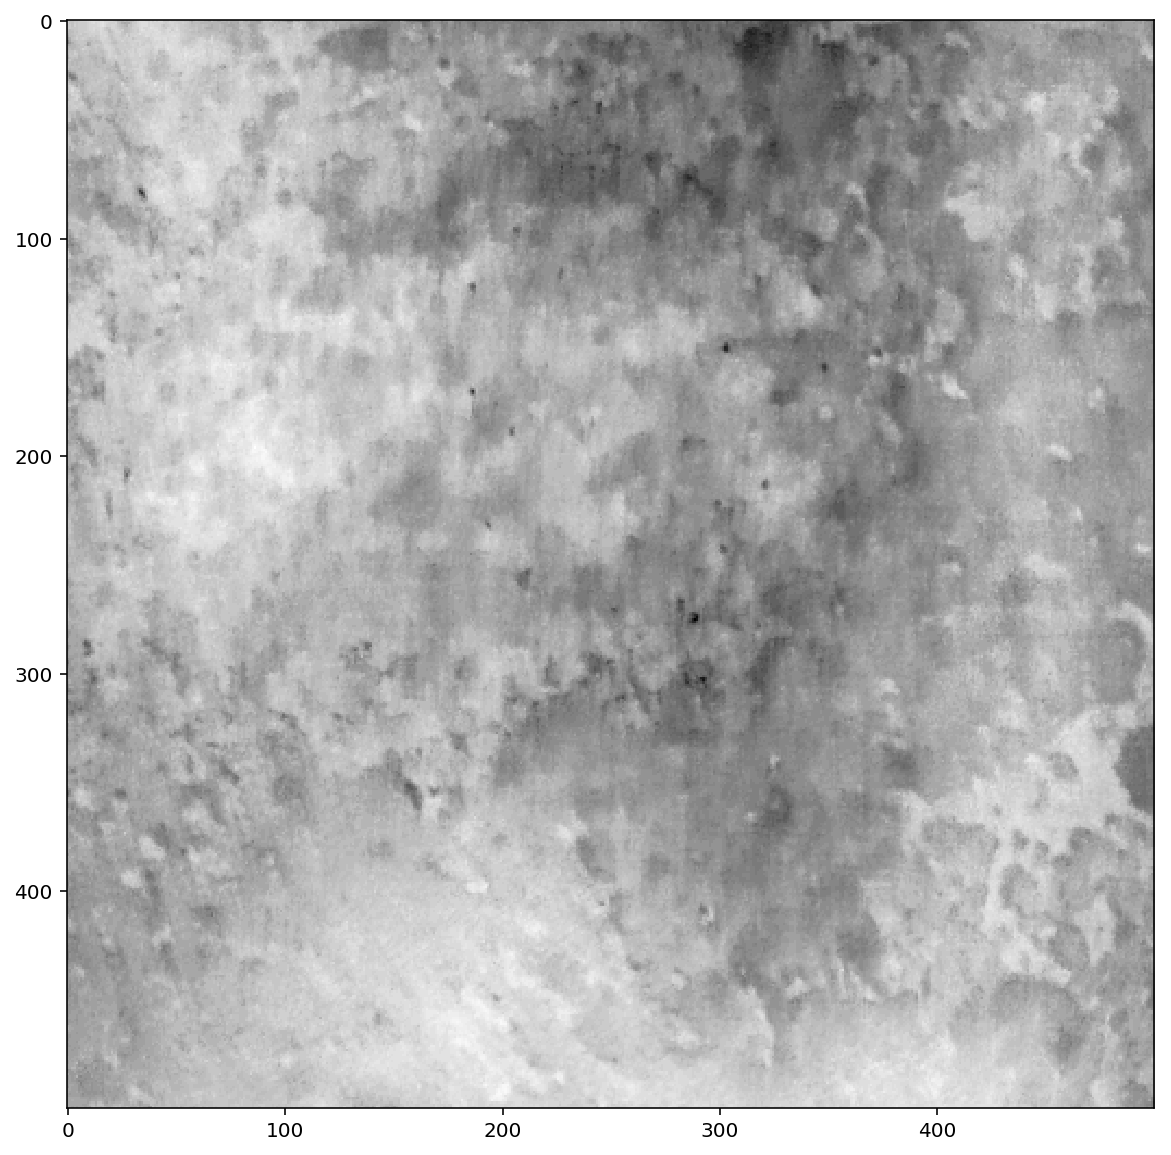

In [5]:
plt.subplots(figsize=(10, 10))
plt.imshow(breeding_grounds, cmap='Greys');

This data is captured at approximately 3cm resolution, so this section of imagery covers roughly $15m^2$ of ground. Thanks to Jacob Virtue (University of Tasmania) for providing the imagery. Notice the small dary marks - these are hotspots which are occupied shearwater burrows (with the entrances being approximately 15cm to 20cm across).

While you can see the hotspots in this region easily the camera is an adaptive camera, so hotspots in different areas will have different values - thus a simple thresholding of the data will not work. However, a visualization of a histogram of the cell values may be useful:

In [6]:
import skimage.exposure

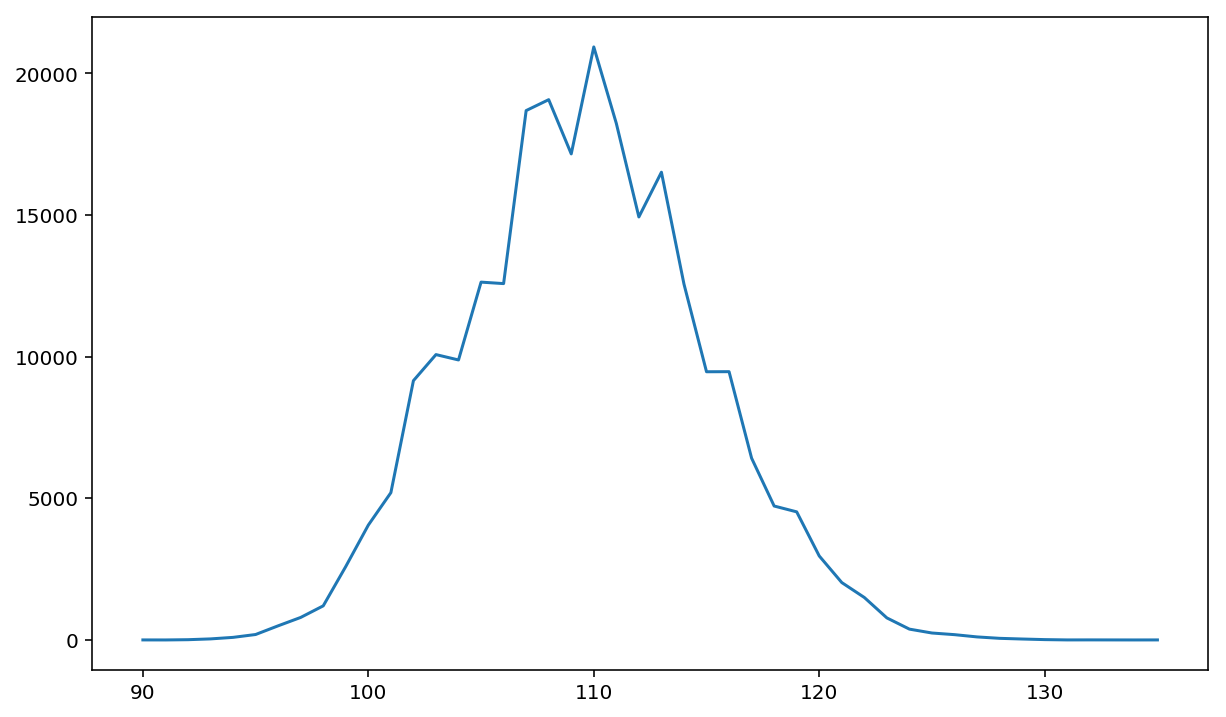

In [7]:
hist, hist_centres = skimage.exposure.histogram(breeding_grounds)
plt.subplots(figsize=(10, 6))
plt.plot(hist_centres, hist);

## Highlighting local maxima using rank filters

The burrows where the shearwaters live are quite small. To help your processes pick out these regions it may be useful to expand these contiguous regions.  This can be done with a rank filtering. Rank filters can be used for several purposes such as:

- image quality enhancement e.g. image smoothing, sharpening
- image pre-processing e.g. noise reduction, contrast enhancement
- feature extraction e.g. border detection, isolated point detection
- post-processing e.g. small object removal, object grouping, contour smoothing

In this case you will use a maximum filter to remove noise and increase the contrast.

In [8]:
from skimage.filters import rank
from skimage.morphology import disk

To visualize easily the outcome of these rank filters you can extract a small region to plot the results of the filtering algorithm.

In [9]:
small_region = breeding_grounds[260:280, 280:300]

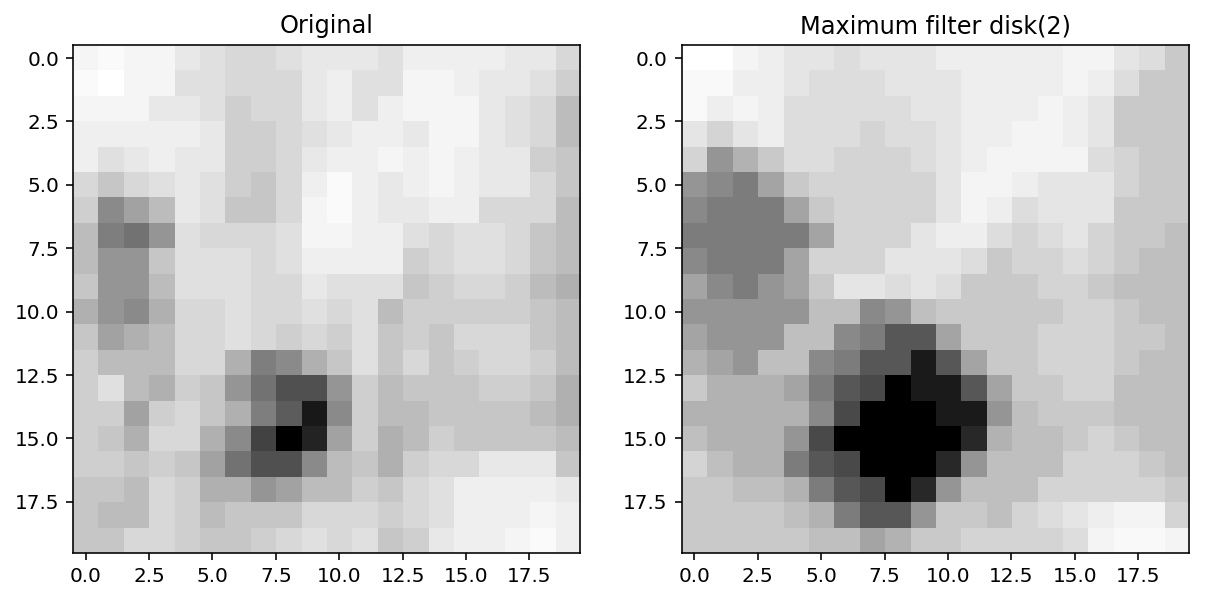

In [10]:
fig, plots = plt.subplots(ncols=2, figsize=(10, 7))
plots[0].imshow(small_region, cmap='Greys')
plots[0].set_title('Original')
plots[1].imshow(
    rank.maximum(small_region, footprint=disk(2)),
    cmap='Greys'
)
plots[1].set_title('Maximum filter disk(2)');

In this case you have supplied the maximum filter a "structuring element" (now called the `footprint`) which represents a disk with a radius of 2 around the centre point:

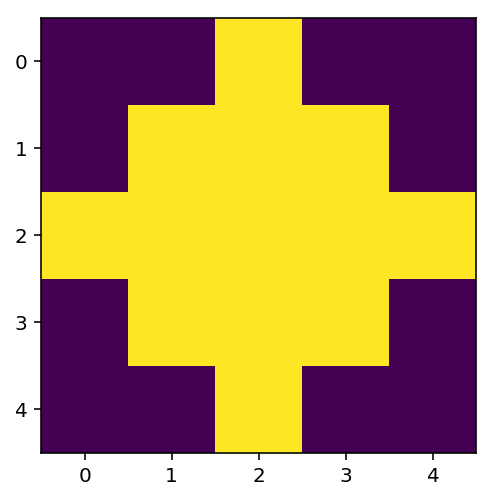

In [11]:
plt.imshow(disk(2));

For each cell in the array the maximum filter will centre the `footprint` and return the maximum value of each cell in this region. This has the effect of removing noise and enhancing local maxima.

### Exercise: Comparing the effects of different structuring elements

The structuring element array can accept any numpy array of ones and zeros - values will be considered for the maximum rank intersecting a value of 1.

Compare the difference in the `small_region` between supplying a `disk(2)` instead of a 5 by 5 array of ones. Plot each result, along with the difference.

In [12]:
# %load solutions/rank_structure_elements.py

You can now apply this to the entire region:

In [13]:
ranked_breeding_grounds = rank.maximum(breeding_grounds, footprint=disk(2))

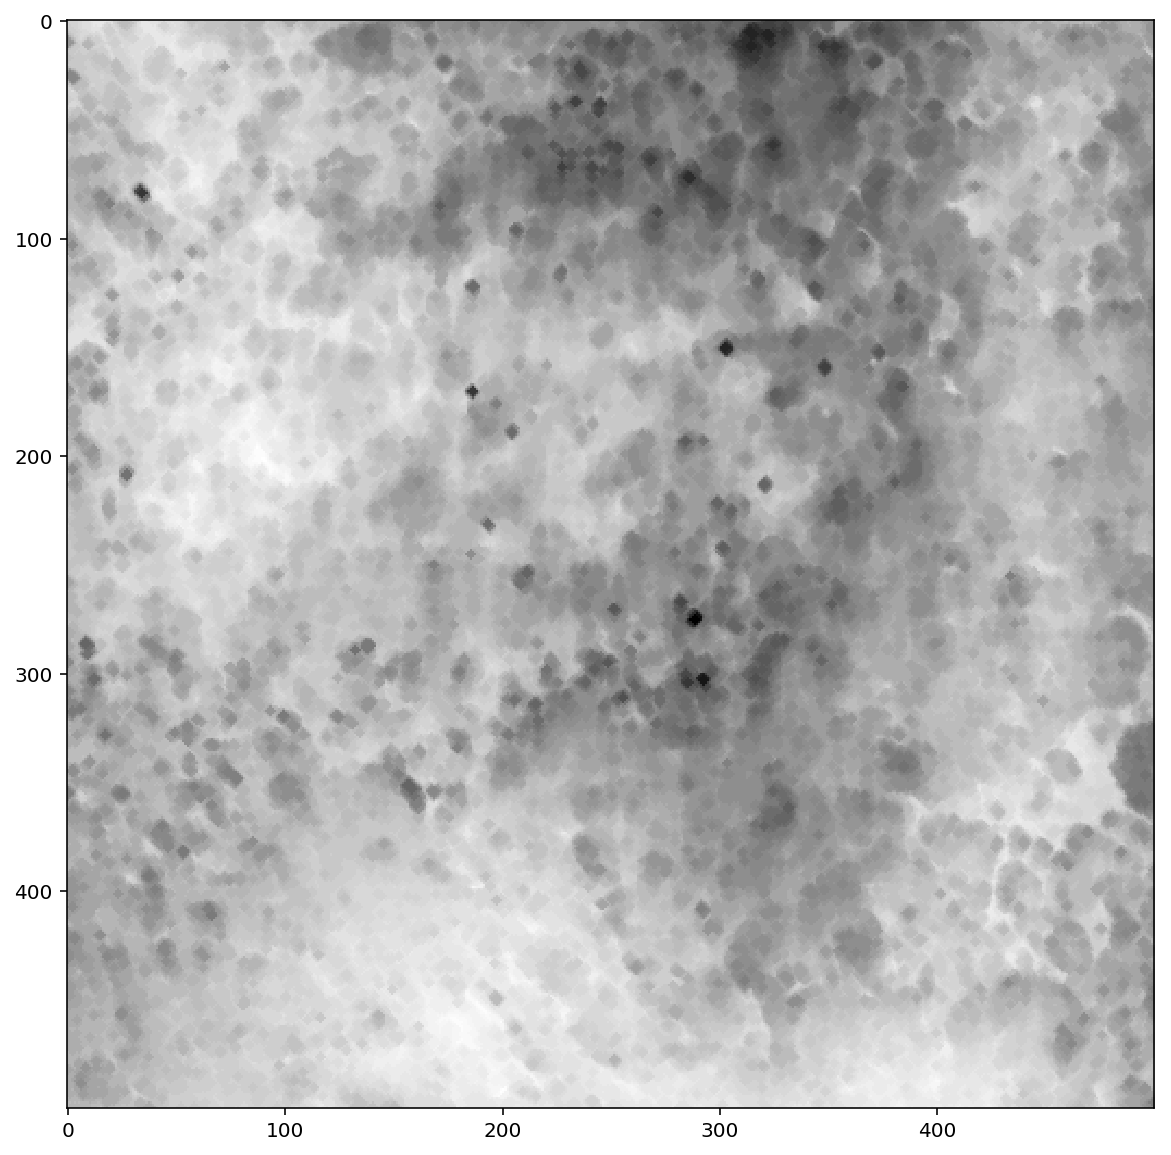

In [14]:
plt.subplots(figsize=(10, 10))
plt.imshow(ranked_breeding_grounds, cmap='Greys');

## Finding the edges of burrows

Now you have smoothed the data to find local maxima you can use another filter to detect the edges of these burrow regions. In this case you will use a Sobel filter which will give you the magnitude of the edges between pixels:

In [15]:
from skimage.filters import sobel

Once again you'll examine a small region to see the effects before applying the filter more broadly.

In [16]:
small_region = ranked_breeding_grounds[260:280, 280:300]

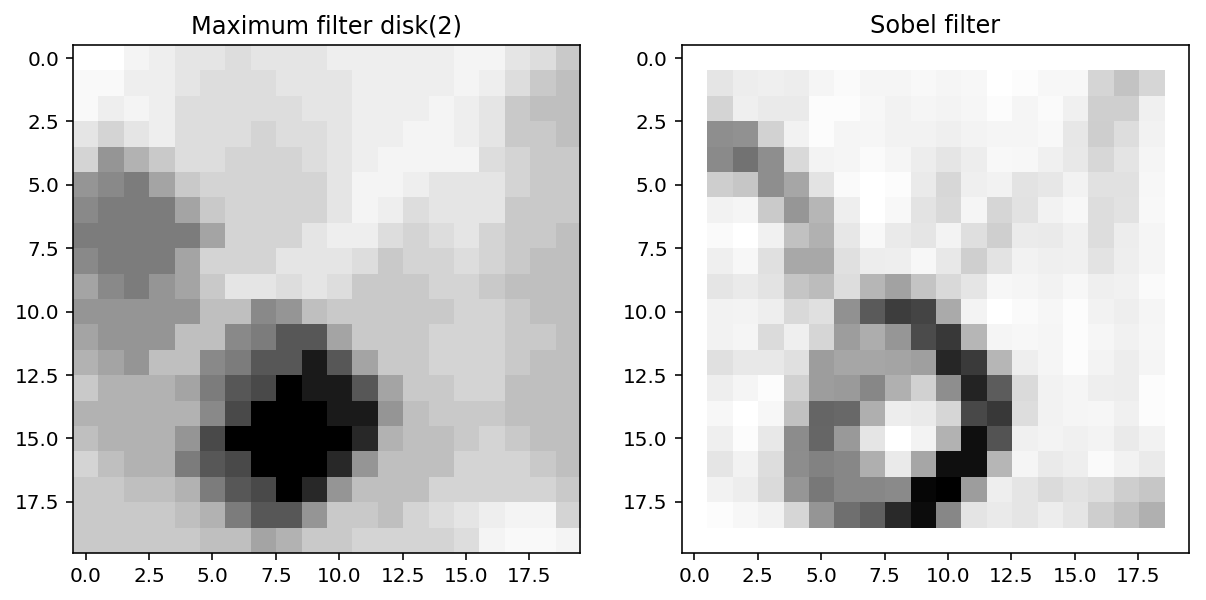

In [17]:
fig, plots = plt.subplots(ncols=2, figsize=(10, 7))
plots[0].imshow(
    small_region,
    cmap='Greys'
)
plots[0].set_title('Original');
plots[1].imshow(
    sobel(small_region),
    cmap='Greys'
)
plots[1].set_title('Sobel filter');

Here you can clearly see the edges of the burrow as highlighted by the filter. You can now apply the filter to the entire region:

In [18]:
sobel_breeding_grounds = sobel(ranked_breeding_grounds)

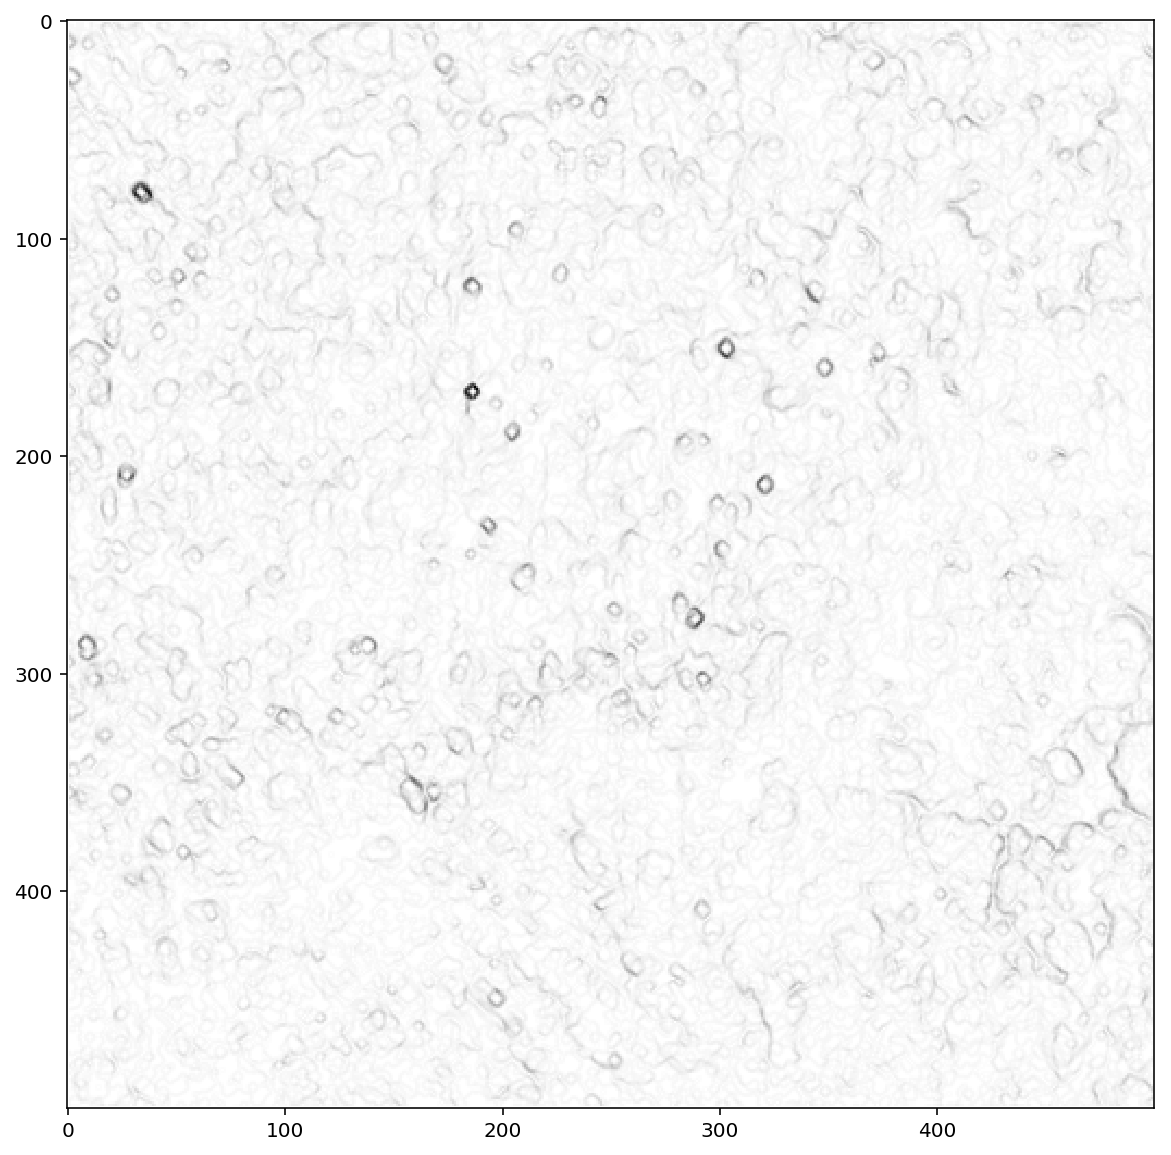

In [19]:
plt.subplots(figsize=(10, 10))
plt.imshow(sobel_breeding_grounds, cmap='Greys');

There are lots of edges in your data though. So you will have to threshold the data to pick only the edges with high magnitudes (i.e. a sharp change from the background temperature to the hotspot of a shearwater burrow). Once again a histogram of these values can help you pick a point to threshold the data:

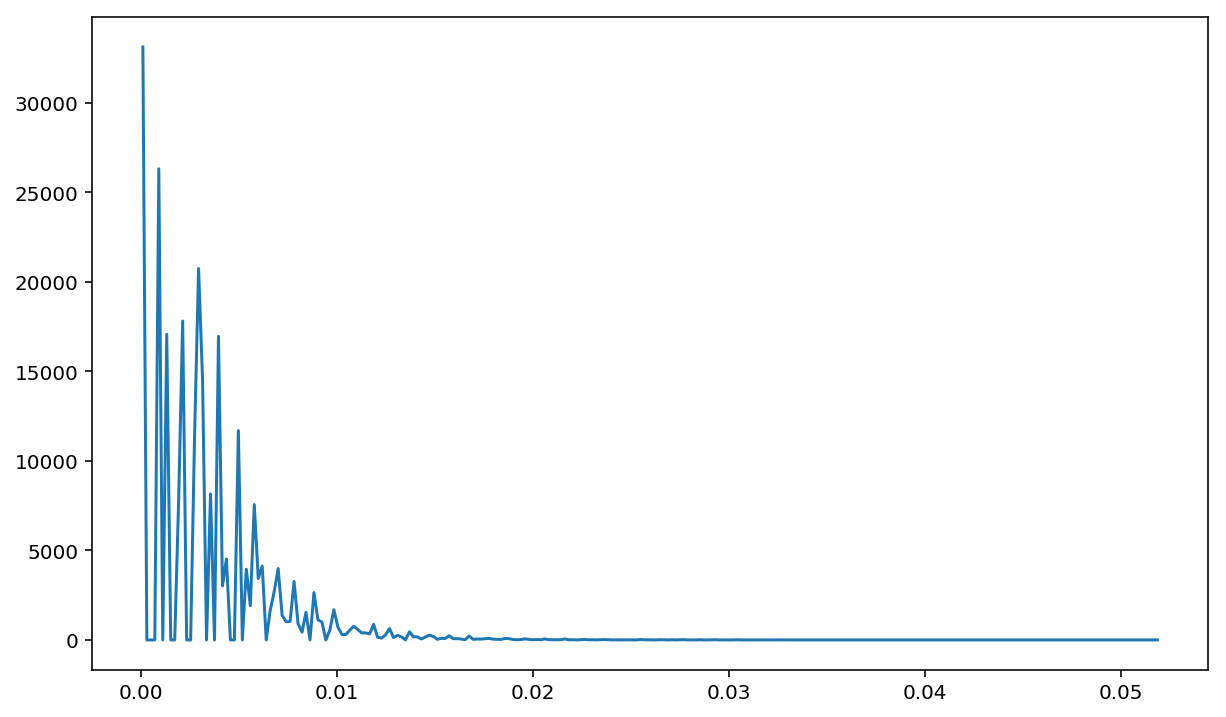

In [20]:
hist, hist_centres = skimage.exposure.histogram(sobel_breeding_grounds)
plt.subplots(figsize=(10, 6))
plt.plot(hist_centres, hist);

In this case filtering magnitudes beneath approximately 0.015 will remove the majority of edges the Sobel filter has found:

In [21]:
threshold_breeding_grounds = np.where(sobel_breeding_grounds >= 0.015, 1, 0)

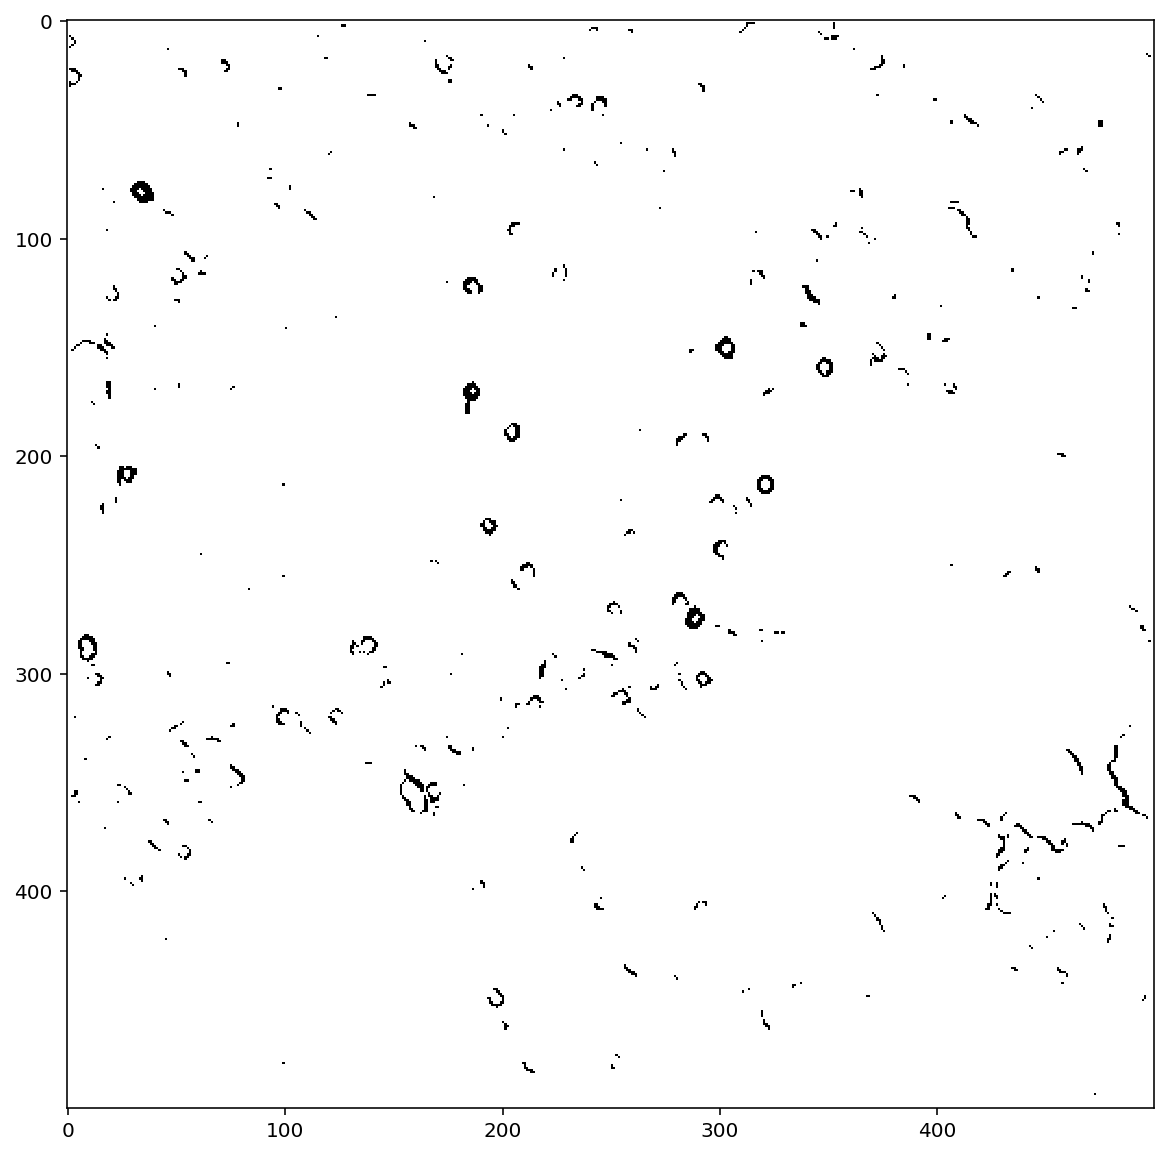

In [22]:
plt.subplots(figsize=(10, 10))
plt.imshow(threshold_breeding_grounds, cmap='Greys');

## Morphological operations

There is still noise in the data though. Ideally you want to remove small "salt and pepper" and thin edges which make up noise in the data, while at the same time keeping the burrows distinct. You can do this through morphology operations. The two basic operations are `dilation` and `erosion`:

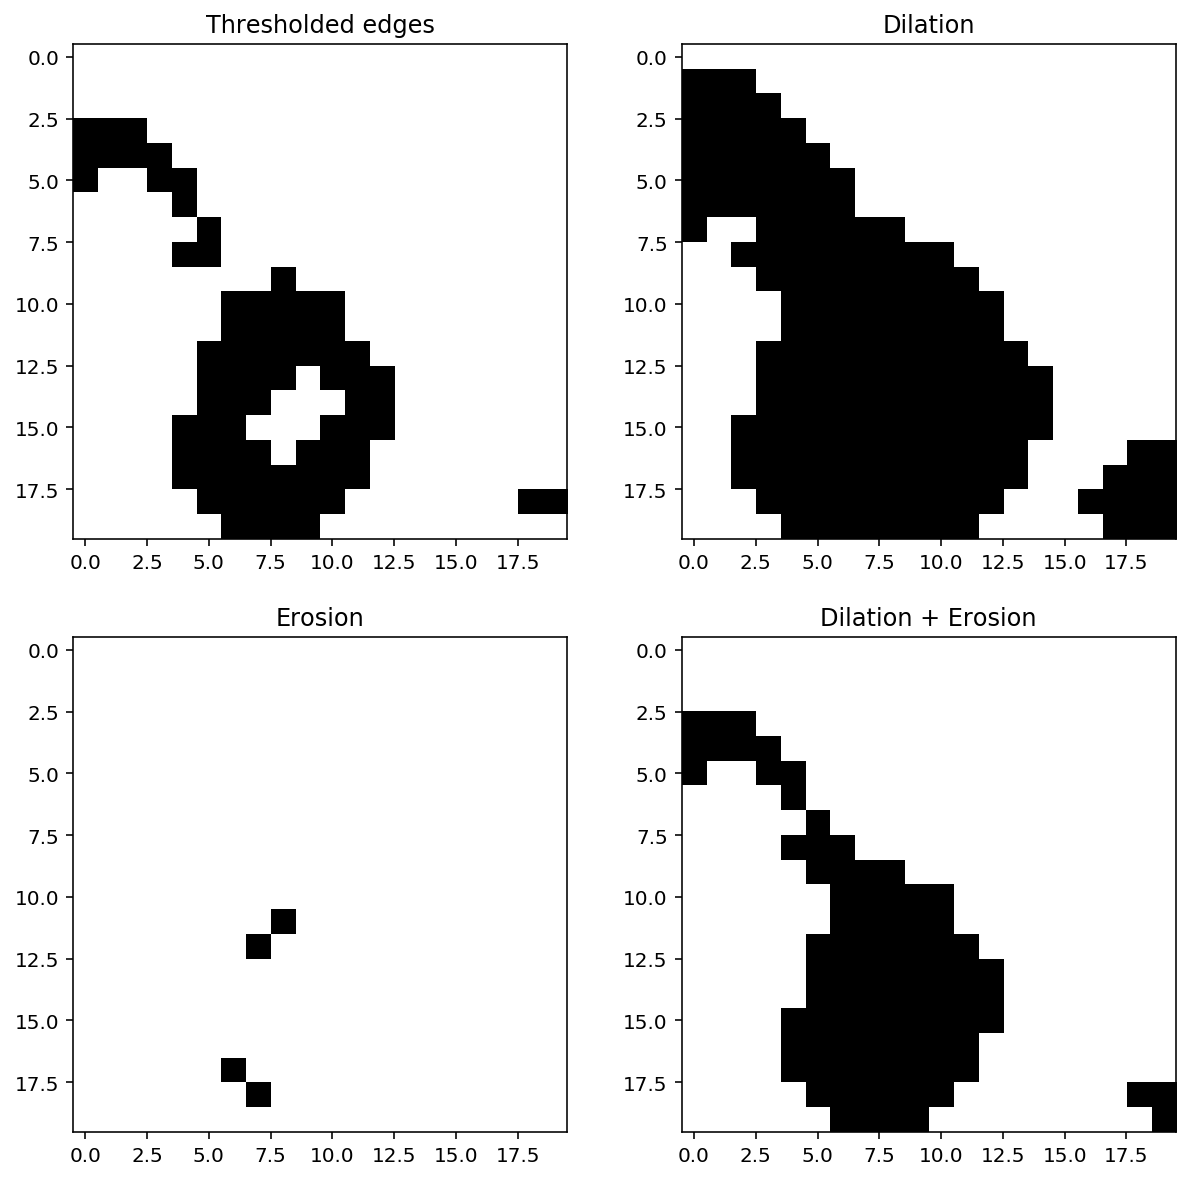

In [23]:
from skimage import morphology

small_region = threshold_breeding_grounds[260:280, 280:300]
fig, plots = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
plots[0, 0].imshow(
    small_region,
    cmap='Greys'
)
plots[0, 0].set_title('Thresholded edges');
plots[0, 1].imshow(
    morphology.dilation(small_region, footprint=disk(2)),
    cmap='Greys'
)
plots[0, 1].set_title('Dilation');
plots[1, 0].imshow(
    morphology.erosion(small_region, footprint=disk(2)),
    cmap='Greys'
)
plots[1, 0].set_title('Erosion');
plots[1, 1].imshow(
    morphology.erosion(morphology.dilation(small_region, footprint=disk(2)), footprint=disk(2)),
    cmap='Greys'
)
plots[1, 1].set_title('Dilation + Erosion');

Dilation expands a region by some structuring element, erosion reduces the region by a structuring element. Since a dilation will fill a hole in a region, following it with an erosion will not open the holes again. This common operation is known as a `closing` operation, and there is a shortcut function for this in the scikit-image library. If you do this for a slightly larger disk than your original filter region (which gave the nest edges) you should close any nest regions:

In [26]:
closed_breeding_grounds = morphology.closing(threshold_breeding_grounds, footprint=disk(3))

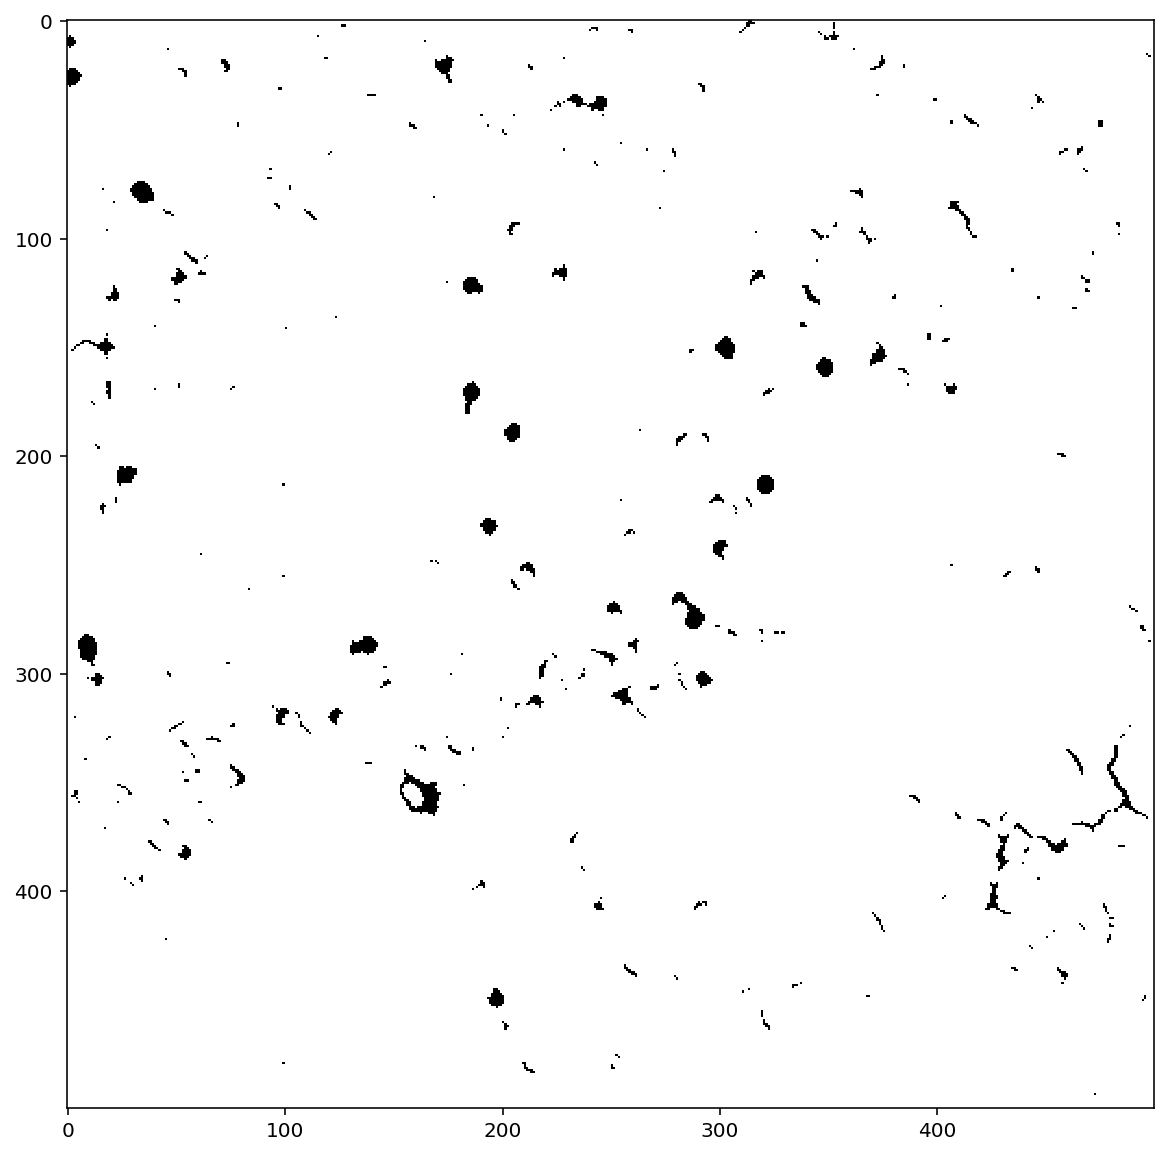

In [27]:
plt.subplots(figsize=(10, 10))
plt.imshow(closed_breeding_grounds, cmap='Greys');

This still leaves thin lines. You can follow the closing operation with an `opening` operation - which is a shortcut for an erosion followed by a dilation. This means all the areas will shrink (and thin lines will disappear), before the larger areas are expanded back to their original size. In this case you'll open by the same sized disk as the original maximum filter:

In [28]:
opened_breeding_grounds = morphology.opening(closed_breeding_grounds, footprint=disk(2))

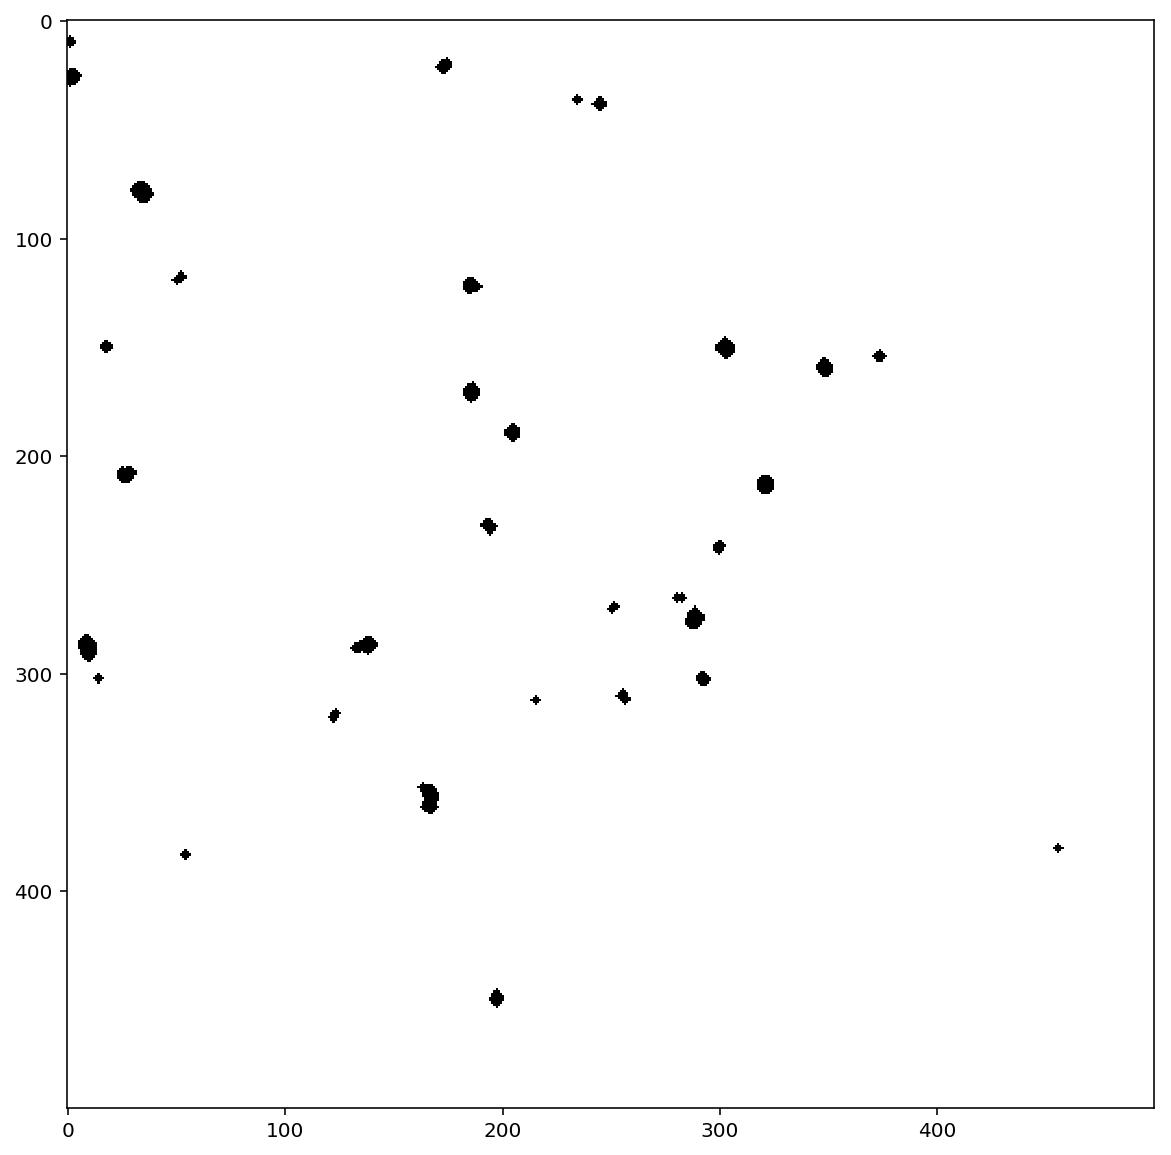

In [29]:
plt.subplots(figsize=(10, 10))
plt.imshow(opened_breeding_grounds, cmap='Greys');

## Labelling discrete regions and outlining nests

You now have candidates for the locations of the nests. The next step is to decide whether these might contain a nest or not by examining each site individually.  To do this you must uniquely label each region:

In [30]:
import skimage.measure

In [31]:
small_region = opened_breeding_grounds[200:300, 250:350]

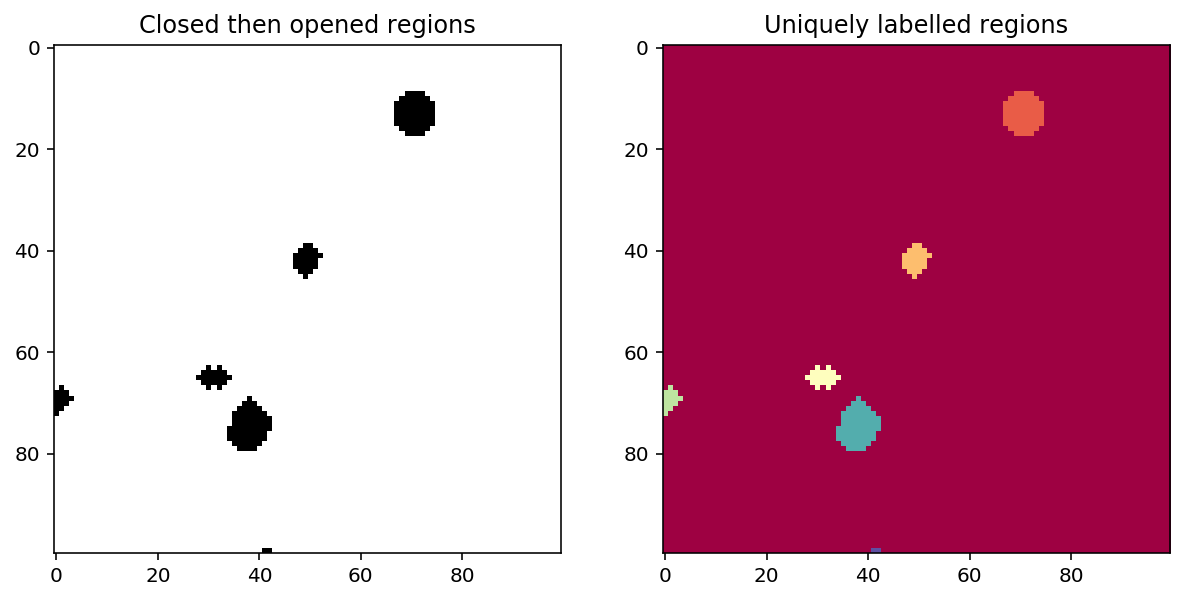

In [32]:
fig, plots = plt.subplots(ncols=2, figsize=(10, 7))
plots[0].imshow(
    small_region,
    cmap='Greys'
)
plots[0].set_title('Closed then opened regions');
plots[1].imshow(
    skimage.measure.label(small_region),
    cmap='Spectral'
)
plots[1].set_title('Uniquely labelled regions');

In [33]:
labelled_breeding_grounds = skimage.measure.label(opened_breeding_grounds)

Given uniquely labelled regions you can now look at the properties of each region. The `regionprops` function create a list of `RegionProperties` which describe a given region:

In [34]:
small_region = labelled_breeding_grounds[200:300, 250:350]

Supplying the original image as the `intensity_image` keyword argument allows you to retrieve the data from this image covered by the labels. From this you can generate additional useful statistics:

In [35]:
burrow_candidates = skimage.measure.regionprops(small_region, intensity_image=breeding_grounds[200:300, 250:350])

### Exercise: Statistics from labelled regions

Write a loop over the `burrow_candidates` and extract the following attributes:

- `intensity_image` (which will have regions not under the labelled region set to zero)
- `label`
- `area`

From the intensity image calculate some standard summary statistics: min, median and max. Finally print out summary statistics for the region.

In [36]:
# %load solutions/burrow_statistics.py

You might at this point want to make some decisions about the properties of burrows. For example, you could consider that most burrows will be from 15cm to 20cm across, which means that in general there should be a minimum area of 10 cells to be useful.

Given this you can filter the labels to only include those regions which match our criteria:

In [37]:
def is_a_burrow(properties):
    """Given region properties determine if region contains a nest"""
    
    return properties.area >= 10

In [38]:
burrow_candidates = skimage.measure.regionprops(labelled_breeding_grounds, intensity_image=breeding_grounds) 

In [39]:
burrow_properties = list(filter(is_a_burrow, burrow_candidates))

## Visualizing the burrows

And finally given only the burrows, we can plot their locations over the top of the original data:

In [40]:
import matplotlib.patches as mpatches

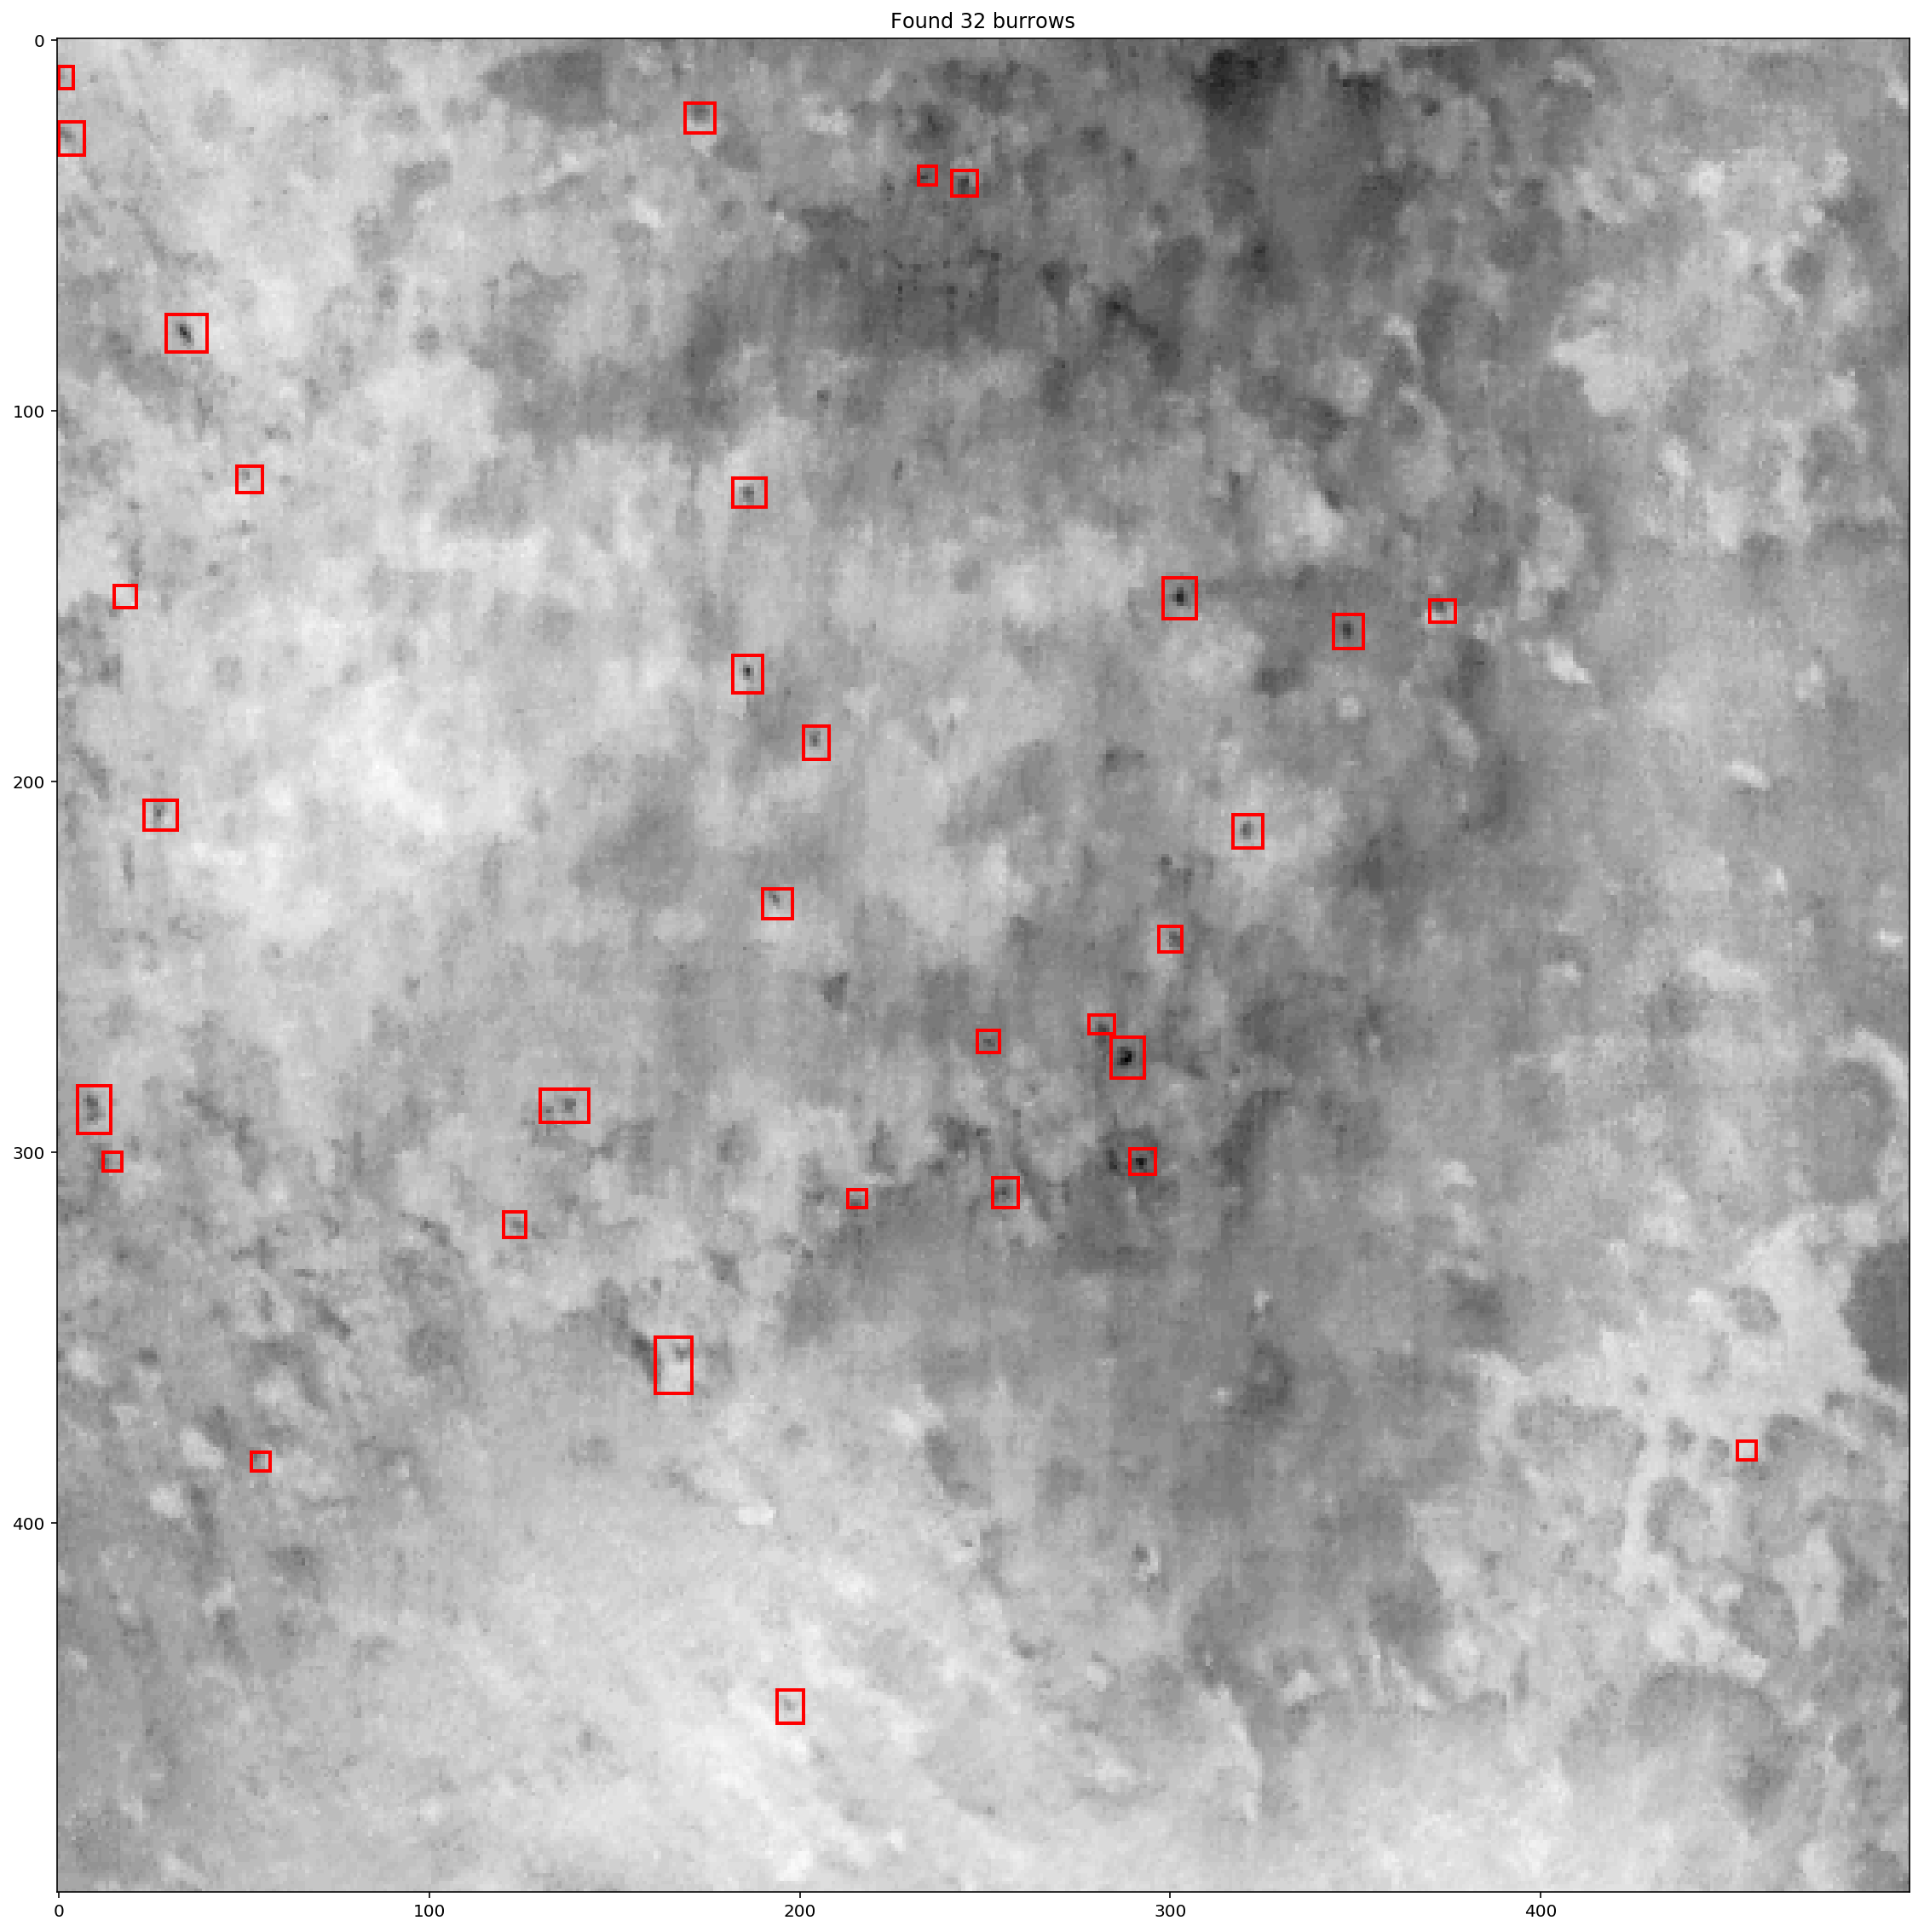

In [41]:
fig, plot = plt.subplots(figsize=(20, 20))
plot.imshow(breeding_grounds, cmap='Greys')

burrow_count = 0

for props in burrow_properties:
            
    burrow_count +=1
    
    # plot the rectangles...
    minr, minc, maxr, maxc = props.bbox
    rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                              fill=False, edgecolor='red', linewidth=2)
    plot.add_patch(rect)
    
plot.set_title(f'Found {burrow_count} burrows');

You may still have some false positives, but certainly there's a good start in finding shearwater burrows.

### Exercise: Threshold potential burrows on intensity

Update the `is_a_burrow` function to include a check that the maximum value of the intensity image should be above 110. How many burrows do you find with this threshold?

In [42]:
# %load solutions/burrow_map.py